In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

In [76]:
mpl.rcParams['font.family'] = 'Nimbus Roman'
plt.rcParams['font.size'] = 15

In [ ]:
top_data = pd.read_hdf("/hpcwork/rwth0934/hep_foundation_model/preprocessed_data/Top_test_discrete_pT_eta_phi.h5").to_numpy()    #200k

top_bin_edges = pd.read_hdf("/home/ew640340/Ph.D./Foundation_Models/New/Top_bin_edges.h5", key="df")
top_logpT_bin_egdes = top_bin_edges["logpT_egdes"][0]
top_eta_phi_bin_egdes = top_bin_edges["eta_phi_egdes"][0]

hf_top = h5py.File("/hpcwork/rwth0934/hep_foundation_model/sampled_jets/TOP_600000_sampled_100000_topk.h5")
top_sampled = np.array(hf_top.get("sampled_jets"))


In [13]:
QCD_data = pd.read_hdf("/hpcwork/rwth0934/hep_foundation_model/preprocessed_data/QCD_test_discrete_pT_eta_phi.h5").to_numpy()    #200k

QCD_bin_edges = pd.read_hdf("/home/ew640340/Ph.D./Foundation_Models/New/QCD_bin_edges.h5", key="df")
QCD_logpT_bin_egdes = QCD_bin_edges["logpT_egdes"][0]
QCD_eta_phi_bin_egdes = QCD_bin_edges["eta_phi_egdes"][0]

hf_QCD = h5py.File("/hpcwork/rwth0934/hep_foundation_model/sampled_jets/QCD_600000_sampled_100000_topk.h5")
QCD_sampled = np.array(hf_QCD.get("sampled_jets"))

In [68]:
# Test with data before discretization
test_data = pd.read_hdf("/home/ew640340/Ph.D./Top_Quark_Tagging_Ref_Data/test_pT_eta_phi.h5")
QCD_data_test = test_data[test_data["is_signal_new"]==0].to_numpy()[:,:300]

QCD_data_pT_test = QCD_data_test[:,0::3]
QCD_data_eta_test = QCD_data_test[:,1::3]
QCD_data_phi_test = QCD_data_test[:,2::3]

QCD_data_logpT_test = np.log(QCD_data_pT_test)

mask_QCD_test = np.isnan(QCD_data_logpT_test)
N_constituents_QCD_test = np.sum(~mask_QCD_test, axis=1)

In [ ]:
def bins_to_continuous(bin_array, edges):
    result = np.full(bin_array.shape, np.nan)

    # gültige In-Range-Bins (1..n_bins)
    valid = (bin_array > 0) & (bin_array < len(edges))
    k = bin_array[valid]

    result[valid] = 0.5 * (edges[k-1] + edges[k])

    return result

def make_continuous(data, logpt_bins, eta_phi_bins):

    jets = data[:, :300]

    logpt_disc = jets[:, 0::3]
    eta_disc = jets[:, 1::3]
    phi_disc = jets[:, 2::3]

    mask = (logpt_disc == -1)
    N_constituents = np.sum(~mask, axis=1)

    logpt_con = bins_to_continuous(logpt_disc, logpt_bins)
    Delta_eta_con = bins_to_continuous(eta_disc, eta_phi_bins)
    Delta_phi_con = bins_to_continuous(phi_disc, eta_phi_bins)

    return N_constituents, logpt_con, Delta_eta_con, Delta_phi_con

def calc_m(logpt_con, Delta_eta_con, Delta_phi_con):

    eta_abs = Delta_eta_con #+ jet_eta[:, None]
    phi_abs = Delta_phi_con #+ jet_phi[:, None]

    # Optional: bring phi in -pi..pi Bereich, falls nötig
    phi_abs = (phi_abs + np.pi) % (2*np.pi) - np.pi

    # pT: exponentiere logpt
    pt_con = np.exp(logpt_con)
    pt_con[np.isnan(pt_con)] = 0.0

    # Für physikalische Summen Constituents mit NaN pT auf 0 setzen:
    pt_con_nonan = np.where(np.isnan(pt_con), 0.0, pt_con)
    # Für angles: Constituents ohne pT können beliebige eta/phi haben; sie tragen nichts bei wenn pt==0.
    eta_for_p = np.where(np.isnan(eta_abs), 0.0, eta_abs)
    phi_for_p = np.where(np.isnan(phi_abs), 0.0, phi_abs)

    pxs = np.cos(phi_for_p) * pt_con_nonan
    pys = np.sin(phi_for_p) * pt_con_nonan
    pzs = np.sinh(eta_for_p) * pt_con_nonan
    Es = np.sqrt(pxs**2 + pys**2 + pzs**2)

    px_j = np.sum(pxs, axis=-1)
    py_j = np.sum(pys, axis=-1)
    pz_j = np.sum(pzs, axis=-1)
    E_j = np.sum(Es, axis=-1)

    m2 = E_j**2 - (px_j**2 + py_j**2 + pz_j**2)
    # numerische Rundungsfehler verhindern negative inside sqrt
    m2 = np.where(m2 < 0, 0.0, m2)
    m_j = np.sqrt(m2)

    return m_j

In [29]:
top_data_N_constituents, top_data_logpT_con, top_data_Delta_eta_con, top_data_Delta_phi_con = make_continuous(top_data, top_logpT_bin_egdes, top_eta_phi_bin_egdes)
top_data_mj = calc_m(top_data_logpT_con, top_data_Delta_eta_con, top_data_Delta_phi_con)

top_sampled_N_constituents, top_sampled_logpT_con, top_sampled_Delta_eta_con, top_sampled_Delta_phi_con = make_continuous(top_sampled, top_logpT_bin_egdes, top_eta_phi_bin_egdes)
top_sampled_mj = calc_m(top_sampled_logpT_con, top_sampled_Delta_eta_con, top_sampled_Delta_phi_con)

print(f"Length top data: {int(np.round(len(top_data_N_constituents)/1000,1))}k")
print(f"Length top samples: {int(np.round(len(top_sampled_N_constituents)/1000,1))}k")

Length top data: 202k
Length top samples: 100k


In [60]:
QCD_data_N_constituents, QCD_data_logpT_con, QCD_data_Delta_eta_con, QCD_data_Delta_phi_con = make_continuous(QCD_data, QCD_logpT_bin_egdes, QCD_eta_phi_bin_egdes)
QCD_data_mj = calc_m(QCD_data_logpT_con, QCD_data_Delta_eta_con, QCD_data_Delta_phi_con)

QCD_data_mj_test = calc_m(QCD_data_logpT_test, QCD_data_eta_test, QCD_data_phi_test)

QCD_sampled_N_constituents, QCD_sampled_logpT_con, QCD_sampled_Delta_eta_con, QCD_sampled_Delta_phi_con = make_continuous(QCD_sampled, QCD_logpT_bin_egdes, QCD_eta_phi_bin_egdes)
QCD_sampled_mj = calc_m(QCD_sampled_logpT_con, QCD_sampled_Delta_eta_con, QCD_sampled_Delta_phi_con)

print(f"Length QCD data: {int(np.round(len(QCD_data_N_constituents)/1000))}k")
print(f"Length QCD samples: {int(np.round(len(QCD_sampled_N_constituents)/1000,1))}k")

Length QCD data: 202k
Length QCD samples: 100k


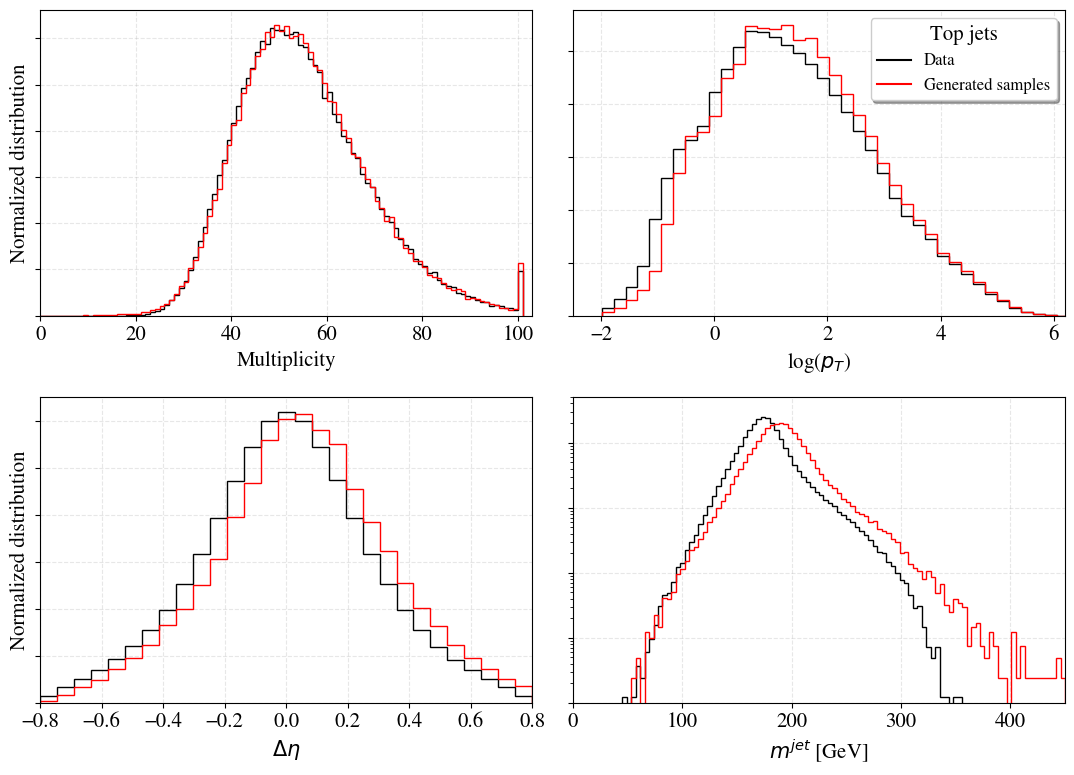

In [83]:
fig1, ax1 = plt.subplots(2,2, figsize=(11,8), dpi=100)
ax1[0,0].hist(top_data_N_constituents, bins = 101, histtype="step", range=(0,101), color="black", density=True)
ax1[0,0].hist(top_sampled_N_constituents, bins = 101, histtype="step", range=(0,101), color="red", density=True)
ax1[0,1].hist(top_data_logpT_con.flatten(), bins = 40, histtype="step", range=(min(QCD_logpT_bin_egdes),max(QCD_logpT_bin_egdes)), color="black", density=True)
ax1[0,1].hist(top_sampled_logpT_con.flatten(), bins = 40, histtype="step", range=(min(QCD_logpT_bin_egdes),max(QCD_logpT_bin_egdes)), color="red", density=True)
ax1[1,0].hist(top_data_Delta_eta_con.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="black", density=True)
ax1[1,0].hist(top_sampled_Delta_eta_con.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="red", density=True)
ax1[1,1].hist(top_data_mj, bins = 110, histtype="step", range=(0,450), color="black", density=True)
ax1[1,1].hist(top_sampled_mj, bins = 110, histtype="step", range=(0,450), color="red", density=True)

ax1[0,0].set_xlabel("Multiplicity")
ax1[0,1].set_xlabel(r"log($p_T$)")
ax1[1,0].set_xlabel(r"$\Delta \eta$")
ax1[1,1].set_xlabel(r"$m^{jet}$ [GeV]")

ax1[0,0].set_ylabel("Normalized distribution")
ax1[1,0].set_ylabel("Normalized distribution")

ax1[1,1].set_yscale("log")

for i in range(2):
    for j in range(2):
        ax1[i,j].tick_params(labelleft=False)
        ax1[i,j].grid(linestyle="--", alpha=0.3)
        ax1[i,j].set_axisbelow(True)

ax1[0,0].set_xlim(0,103)
ax1[0,1].set_xlim(-2.5,6.2)
ax1[1,0].set_xlim(-0.8,0.8)
ax1[1,1].set_xlim(0,450)

ax1[1,1].set_ylim(10**(-6),5*10**(-2))

ax1[0,1].plot(-5,0, color="black", label="Data")
ax1[0,1].plot(-5,0, color="red", label="Generated samples")
ax1[1,0].set_xticks(np.linspace(-0.8,0.8,9))

ax1[0,1].legend(loc="upper right", title="Top jets", shadow=True, fontsize=12)
plt.tight_layout()
plt.show()


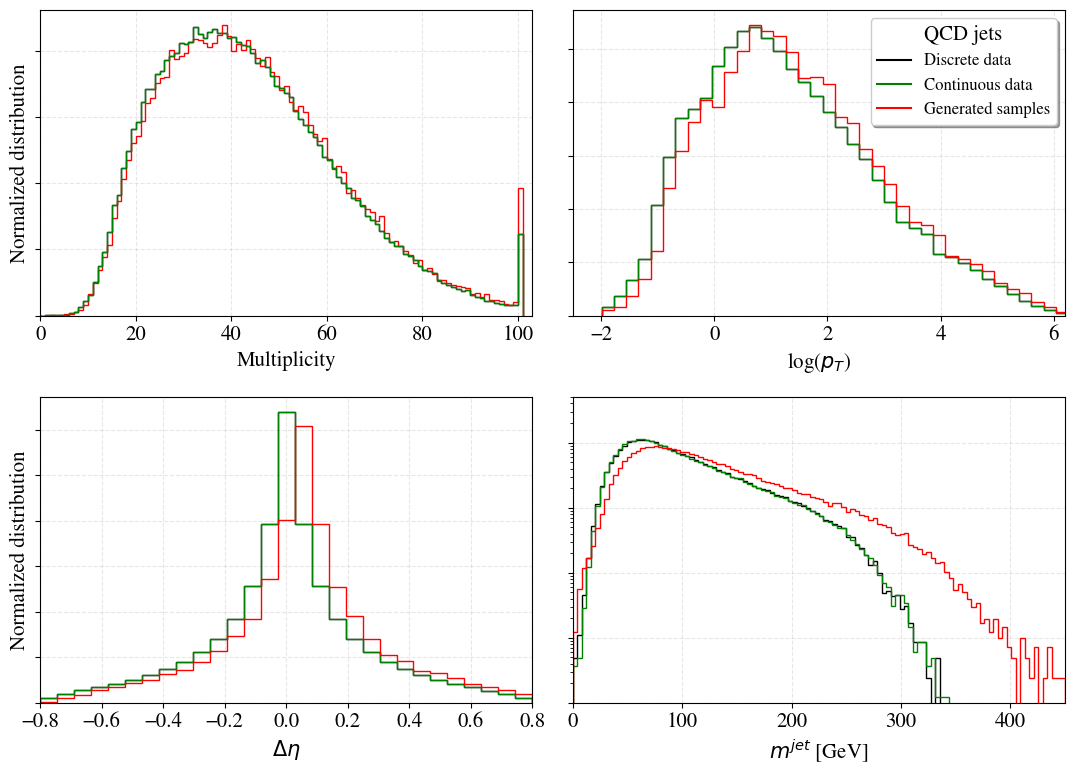

In [82]:
fig1, ax1 = plt.subplots(2,2, figsize=(11,8), dpi=100)
ax1[0,0].hist(QCD_data_N_constituents, bins = 101, histtype="step", range=(0,101), color="black", density=True)
ax1[0,0].hist(QCD_sampled_N_constituents, bins = 101, histtype="step", range=(0,101), color="red", density=True)
ax1[0,0].hist(N_constituents_QCD_test, bins = 101, histtype="step", range=(0,101), color="green", density=True)
ax1[0,1].hist(QCD_data_logpT_con.flatten(), bins = 39, histtype="step", range=(min(QCD_logpT_bin_egdes),max(QCD_logpT_bin_egdes)), color="black", density=True)
ax1[0,1].hist(QCD_data_logpT_test.flatten(), bins = 39, histtype="step", range=(min(QCD_logpT_bin_egdes),max(QCD_logpT_bin_egdes)), color="green", density=True)
ax1[0,1].hist(QCD_sampled_logpT_con.flatten(), bins = 39, histtype="step", range=(min(QCD_logpT_bin_egdes),max(QCD_logpT_bin_egdes)), color="red", density=True)
ax1[1,0].hist(QCD_data_Delta_eta_con.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="black", density=True)
ax1[1,0].hist(QCD_data_eta_test.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="green", density=True)
ax1[1,0].hist(QCD_sampled_Delta_eta_con.flatten(), bins = 29, histtype="step", range=(-0.8,0.8), color="red", density=True)
ax1[1,1].hist(QCD_data_mj, bins = 110, histtype="step", range=(0,450), color="black", density=True)
ax1[1,1].hist(QCD_data_mj_test, bins = 110, histtype="step", range=(0,450), color="green", density=True)
ax1[1,1].hist(QCD_sampled_mj, bins = 110, histtype="step", range=(0,450), color="red", density=True)

ax1[0,0].set_xlabel("Multiplicity")
ax1[0,1].set_xlabel(r"log($p_T$)")
ax1[1,0].set_xlabel(r"$\Delta \eta$")
ax1[1,1].set_xlabel(r"$m^{jet}$ [GeV]")

ax1[0,0].set_ylabel("Normalized distribution")
ax1[1,0].set_ylabel("Normalized distribution")

ax1[1,1].set_yscale("log")

for i in range(2):
    for j in range(2):
        ax1[i,j].tick_params(labelleft=False)
        ax1[i,j].grid(linestyle="--", alpha=0.3)
        ax1[i,j].set_axisbelow(True)

ax1[0,0].set_xlim(0,103)
ax1[0,1].set_xlim(-2.5,6.2)
ax1[1,0].set_xlim(-0.8,0.8)
ax1[1,1].set_xlim(0,450)

ax1[1,1].set_ylim(10**(-6),5*10**(-2))

ax1[0,1].plot(-5,0, color="black", label="Discrete data")
ax1[0,1].plot(-5,0, color="green", label="Continuous data")
ax1[0,1].plot(-5,0, color="red", label="Generated samples")
ax1[1,0].set_xticks(np.linspace(-0.8,0.8,9))

ax1[0,1].legend(loc="upper right", title="QCD jets", shadow=True, fontsize=12)
plt.tight_layout()
plt.show()
